# Machine Learning: Demo

---

## 1. Supervised Learning

### 1.1. Classification

#### Classification step by step

Accuracy: 1.0


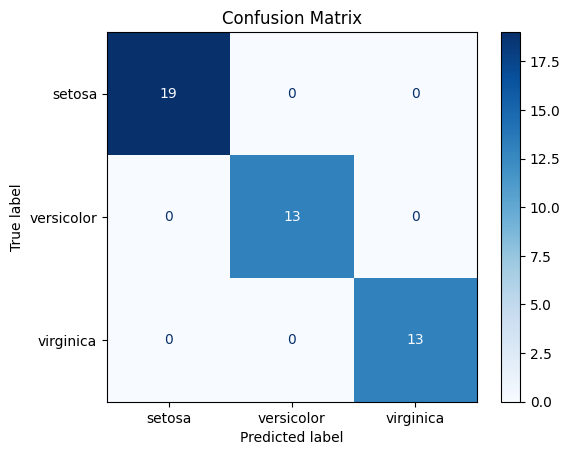

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [1]:
# Ví dụ bài toán phân loại hoa Iris dùng kNN (k-Nearest Neighbors)
# Dataset: Iris
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Bước 1: Nạp dữ liệu Iris
iris = load_iris()
X = iris.data
y = iris.target

# Bước 2: Chia dữ liệu train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Bước 3: Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Bước 4: Huấn luyện mô hình kNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

# Bước 5: Dự đoán
y_pred = model.predict(X_test_scaled)

# Bước 6: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Bước 7: Tạo Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# Vẽ Confusion Matrix với màu tùy chỉnh
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
# Chọn màu: plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Reds, plt.cm.Purples
disp.plot(cmap=plt.cm.Blues) 
plt.title("Confusion Matrix")
plt.show()

# Bước 8: In Classification Report
print("Classification Report:")
report = classification_report(y_test, y_pred)
print(report)

#### Predictions based on new data

In [2]:
# Dự đoán trên dữ liệu mới (5 mẫu ngẫu nhiên)
import numpy as np

# Bước 1: Xác định khoảng giá trị của từng đặc trưng trong dữ liệu gốc
# Điều này giúp sinh dữ liệu ngẫu nhiên hợp lý
feature_min = X.min(axis=0)
feature_max = X.max(axis=0)

# Bước 2: Sinh ngẫu nhiên 5 mẫu dữ liệu mới
# Mỗi mẫu có 4 đặc trưng giống dữ liệu Iris
X_new = np.random.uniform(
    low=feature_min,
    high=feature_max,
    size=(5, X.shape[1])
)

print("Dữ liệu mới (chưa chuẩn hóa):")
print(X_new)

# Bước 3: Chuẩn hóa dữ liệu mới
# Phải dùng scaler đã fit trên tập train
X_new_scaled = scaler.transform(X_new)

print("Dữ liệu mới (đã chuẩn hóa):")
print(X_new_scaled)

# Bước 4: Dự đoán nhãn cho dữ liệu mới
y_new_pred = model.predict(X_new_scaled)

print("\nKết quả dự đoán:")
for i in range(len(X_new)):
    print(f"Mẫu {i+1}: dự đoán lớp =", iris.target_names[y_new_pred[i]])

Dữ liệu mới (chưa chuẩn hóa):
[[4.93817896 3.81004063 6.69959923 1.40177102]
 [4.68959947 2.65068598 4.12635826 1.51149124]
 [6.89480337 3.10258323 4.47160355 0.36109699]
 [5.26735538 3.49987008 4.76045155 1.22112598]
 [5.66287801 2.12003534 4.05314913 2.38040757]]
Dữ liệu mới (đã chuẩn hóa):
[[-1.09085899  1.92011841  1.65142717  0.22014184]
 [-1.3905956  -0.86070786  0.14936452  0.36857785]
 [ 1.26843447  0.22321217  0.3508925  -1.18774355]
 [-0.69393878  1.17614379  0.51950003 -0.02424545]
 [-0.21701845 -2.13352567  0.10663059  1.54409926]]

Kết quả dự đoán:
Mẫu 1: dự đoán lớp = versicolor
Mẫu 2: dự đoán lớp = versicolor
Mẫu 3: dự đoán lớp = versicolor
Mẫu 4: dự đoán lớp = versicolor
Mẫu 5: dự đoán lớp = virginica


### 1.2. Regression

#### Regression step by step

Mean Squared Error: 0.003560000000000016
R2 score: 0.9824197530864197


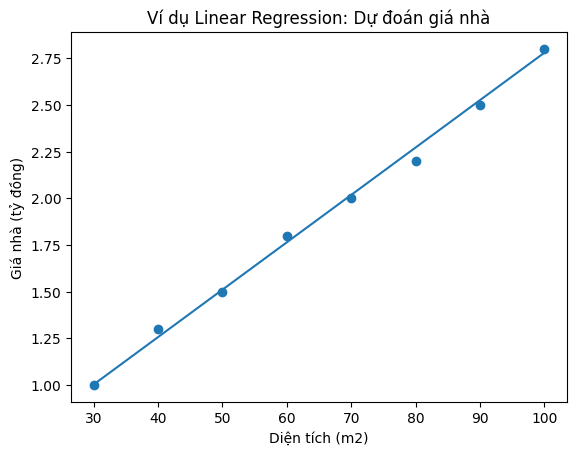

In [3]:
# Ví dụ bài toán Regression: dự đoán giá nhà theo diện tích
# Mô hình: Linear Regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Tạo dữ liệu giả lập
# Diện tích nhà (m2)
# -1: NumPy tự suy ra số hàng sao cho phù hợp với tổng số phần tử
X = np.array([30, 40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)

# Giá nhà (tỷ đồng)
y = np.array([1.0, 1.3, 1.5, 1.8, 2.0, 2.2, 2.5, 2.8])

# 2. Chia dữ liệu train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 3. Khởi tạo và huấn luyện mô hình Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Dự đoán trên tập test
y_pred = model.predict(X_test)

# 5. Đánh giá mô hình
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 score:", r2)

# 6. Vẽ dữ liệu và đường hồi quy
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Diện tích (m2)")
plt.ylabel("Giá nhà (tỷ đồng)")
plt.title("Ví dụ Linear Regression: Dự đoán giá nhà")
plt.show()

#### Predictions based on new data

In [4]:
# Sinh ngẫu nhiên 5 dữ liệu mới (diện tích nhà)
# Giả sử diện tích nằm trong khoảng 30 – 120 m2
np.random.seed(0)
X_new = np.random.uniform(30, 120, size=5).reshape(-1, 1)

# Dự đoán giá nhà cho 5 dữ liệu mới
y_new_pred = model.predict(X_new)

print("Dữ liệu mới (diện tích m2) và giá dự đoán (tỷ đồng):")
for x, y_hat in zip(X_new, y_new_pred):
    print(f"Diện tích: {x[0]:.1f} m2  -->  Giá dự đoán: {y_hat:.2f} tỷ")

Dữ liệu mới (diện tích m2) và giá dự đoán (tỷ đồng):
Diện tích: 79.4 m2  -->  Giá dự đoán: 2.26 tỷ
Diện tích: 94.4 m2  -->  Giá dự đoán: 2.64 tỷ
Diện tích: 84.2 m2  -->  Giá dự đoán: 2.38 tỷ
Diện tích: 79.0 m2  -->  Giá dự đoán: 2.25 tỷ
Diện tích: 68.1 m2  -->  Giá dự đoán: 1.97 tỷ


## 2. Unsupervised Learning


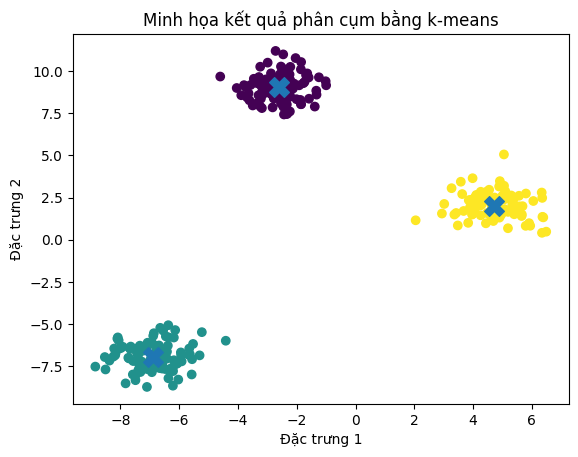

In [5]:
# Ví dụ Clustering dùng k-means và vẽ minh họa kết quả phân cụm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Tạo tập dữ liệu giả lập gồm 3 cụm với 300 điểm dữ liệu
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.8,
    random_state=42
)

# 2. Khởi tạo mô hình k-means với k = 3
kmeans = KMeans(n_clusters=3, random_state=42)

# 3. Huấn luyện mô hình và gán nhãn cụm
labels = kmeans.fit_predict(X)

# 4. Lấy tọa độ các tâm cụm
centers = kmeans.cluster_centers_

# 5. Vẽ kết quả phân cụm
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200
)

plt.xlabel("Đặc trưng 1")
plt.ylabel("Đặc trưng 2")
plt.title("Minh họa kết quả phân cụm bằng k-means")
plt.show()

#### Predictions based on new data

5 điểm dữ liệu mới và cụm được gán:
Điểm 1: [-2.45626033  5.62150376]  -->  Cụm 0
Điểm 2: [-8.8551873  -2.70157978]  -->  Cụm 1
Điểm 3: [-6.60445289 -6.88299415]  -->  Cụm 1
Điểm 4: [-5.99811891 -1.84081783]  -->  Cụm 1
Điểm 5: [-2.76713798  2.00730891]  -->  Cụm 0


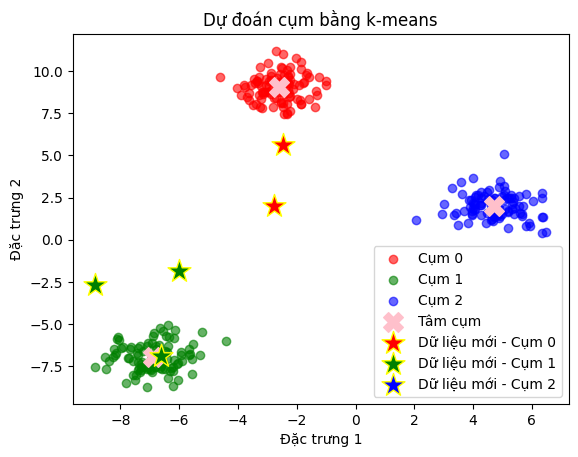

In [6]:
# Sinh ngẫu nhiên 5 điểm dữ liệu mới
# Giả sử dữ liệu mới nằm trong cùng không gian với dữ liệu gốc
np.random.seed(1)
X_new = np.random.uniform(
    low=X.min(axis=0),
    high=X.max(axis=0),
    size=(5, 2)
)

# Dự đoán cụm cho các điểm mới
new_labels = kmeans.predict(X_new)

print("5 điểm dữ liệu mới và cụm được gán:")
for i, (point, label) in enumerate(zip(X_new, new_labels)):
    print(f"Điểm {i+1}: {point}  -->  Cụm {label}")
    
# Định nghĩa màu cho từng cụm
cluster_colors = {
    0: 'red',
    1: 'green',
    2: 'blue'
}

# Vẽ các điểm dữ liệu theo từng cụm với màu cố định
for i in range(3):
    plt.scatter(
        X[labels == i, 0],
        X[labels == i, 1],
        c=cluster_colors[i],
        label=f"Cụm {i}",
        alpha=0.6
    )

# Vẽ tâm cụm
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='pink',
    marker='X',
    s=200,
    label='Tâm cụm'
)

# Vẽ dữ liệu mới (ngôi sao) theo màu cụm dự đoán
for i in range(3):
    plt.scatter(
        X_new[new_labels == i, 0],
        X_new[new_labels == i, 1],
        c=cluster_colors[i],
        marker='*',
        s=300,
        edgecolors='yellow',
        label=f'Dữ liệu mới - Cụm {i}'
    )

plt.xlabel("Đặc trưng 1")
plt.ylabel("Đặc trưng 2")
plt.title("Dự đoán cụm bằng k-means")
plt.legend()
plt.show()